In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3.0)

20.0

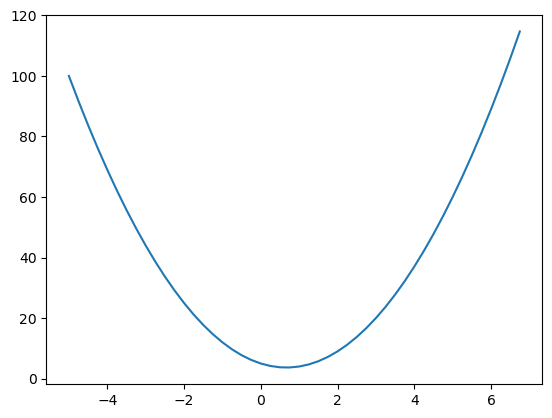

In [4]:
xs=np.arange(-5,7,0.25)
ys=f(xs)
plt.plot(xs,ys)
plt.show() 
#为什么需要plt.show()？
# 因为在某些环境中（如Jupyter Notebook）需要调用plt.show()来显示图形，而在其他环境中（如Python脚本）则不需要。
# plt.show()会阻止代码继续执行，直到图形窗口被关闭，这对于交互式环境非常有用。

In [5]:
h=0.0000001
x=2/3
print(f(x))
print(f(x+h))
print((f(x+h)-f(x))/h)

3.666666666666667
3.6666666666666967
2.9753977059954195e-07


In [6]:
# let grt more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [7]:
h=0.0001

a=2.0
b=-3.0
c=10.0
d1=a*b+c
print('d1=',d1)


# a+=h
# b+=h
c+=h

d2=a*b+c
print('d2=',d2)

print('slope=',(d2-d1)/h)



d1= 4.0
d2= 4.0001
slope= 0.9999999999976694


In [166]:
class Value:
    # __init__是一个特殊方法，用于在创建对象时初始化对象的属性。
    # self是一个指向当前对象的引用，允许我们在类的方法中访问对象的属性和方法。
    # 举例来说，当我们创建一个Value对象时，__init__方法会被自动调用，并且self参数会指向新创建的对象。我们可以使用self.data来存储传入的数据，并在其他方法中访问它。
    def __init__(self,data,_children=(),_op='',label=''): 
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label

    # __repr__是一个特殊方法，用于定义对象的字符串表示。
    # 当我们打印一个对象或者使用str()函数时，__repr__方法会被调用来返回一个字符串，描述这个对象的内容。
    def __repr__(self):
        return f"Value(data={self.data})"
    
    # def __str__(self):
    #     return f"Value(data={self.data})"

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')

        def _backward():
            self.grad+=out.grad*1.0
            other.grad+=out.grad*1.0
        out._backward=_backward

        return out
    
    def __radd__(self, other):
        return self+other

    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out=Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad+=other*(self.data**(other-1))*out.grad
        out._backward=_backward

        return out
    
    def __rmul__(self, other):
        return self*other
    
    def __truediv__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data/other.data,(self,other),'/')

        def _backward():
            self.grad+=out.grad*(1/other.data)
            other.grad+=out.grad*(-self.data/(other.data**2))
        out._backward=_backward

        return out
    
    def __rtruediv__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        return other/self
    
    def __neg__(self):
        return self*(-1)
    
    def __sub__(self, other):
        return self+(-other)
    
    def __rsub__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        return other-self

    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward

        return out
    
    # def tanh(self):
    #     t=((2*self).exp()-1)/((2*self).exp()+1)
    #     out=Value(t,(self,),'tanh')

    #     def _backward():
    #         self.grad+=(1-t.data**2)*out.grad
    #     out._backward=_backward

    #     return out
    
    def backward(self):
        
        topo=[]; 
        visited=set() 
        def build_topo(v): 
            if v not in visited: 
                visited.add(v) 
                for child in v._prev: 
                    build_topo(child) 
                topo.append(v) 
        build_topo(self) 

        self.grad=1.0
        for node in reversed(topo):
            node._backward()



In [167]:
a=Value(2.0)
b=Value(-4.0)
1-a**int((2-b).data)/b-1
a.tanh()

Value(data=0.9640275800758169)

In [168]:
from graphviz import Digraph 
def trace(root): 
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR=left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

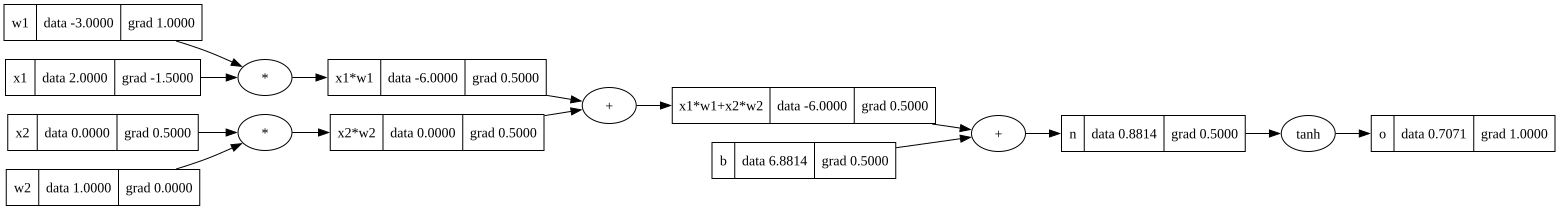

In [171]:
x1= Value(2.0,label='x1')
x2= Value(0.0, label='x2')
w1= Value(-3.0,label='w1')
w2= Value(1.0,label='w2')
b= Value(6.8813735870195432,label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'
o.backward()
draw_dot(o)

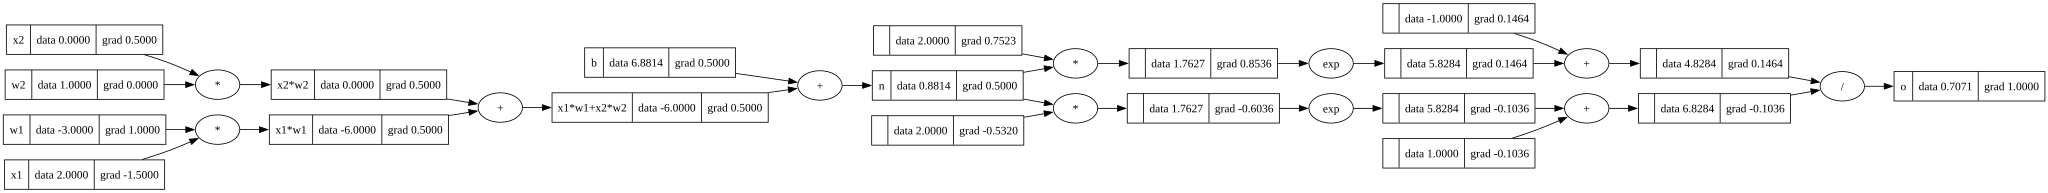

In [179]:
x1= Value(2.0,label='x1')
x2= Value(0.0, label='x2')
w1= Value(-3.0,label='w1')
w2= Value(1.0,label='w2')
b= Value(6.8813735870195432,label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b; n.label='n'


o=((2*n).exp()-1)/((2*n).exp()+1); 
o.label='o'

o.backward()
draw_dot(o)

In [180]:
import torch

In [196]:
x1 =torch.Tensor([2.0]).double() ; x1.requires_grad = True ;
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True ;
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True ;
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True ;
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True ;
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()
# n.backward()
print("--")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('b', b.grad.item())




0.7071066904050358
--
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737
b 0.5000001283844369


In [337]:
import random

# ============================================================
# 神经网络的三层抽象：Neuron → Layer → MLP
# 
# 结构示意（以 MLP(3, [4, 4, 1]) 为例）：
#
#   输入层(3)      隐藏层1(4)     隐藏层2(4)     输出层(1)
#   x1 ──────►  [n1, n2, n3, n4] ──► [n1, n2, n3, n4] ──► [n1] ──► y
#   x2 ──────►                                              
#   x3 ──────►                                              
#
# 每个箭头 ──► 都代表"全连接"：前一层的所有输出都作为下一层每个神经元的输入
# ============================================================

class Neuron:
    """
    单个神经元：接收 nin 个输入，输出 1 个标量值
    数学公式：y = tanh(w1*x1 + w2*x2 + ... + wn*xn + b)
    
    示意图（nin=3 的情况）：
        x1 ──w1──┐
        x2 ──w2──┼──► Σ(wi*xi) + b ──► tanh ──► y
        x3 ──w3──┘
    """
    def __init__(self, nin):
        # nin = number of inputs，即这个神经元有多少个输入
        
        # 为每个输入创建一个权重(weight)，随机初始化为 [-1, 1] 之间的值
        # 列表推导式：生成 nin 个 Value 对象组成的列表
        # 例如 nin=3 → self.w = [Value(0.23), Value(-0.87), Value(0.41)]
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        
        # 偏置(bias)，也随机初始化为 [-1, 1] 之间的值
        # 偏置的作用：让神经元即使所有输入为 0 时也能输出非零值，增加模型的灵活性
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # __call__ 让 Neuron 对象可以像函数一样被调用：neuron(x)
        # x 是输入列表，长度应该等于 nin
        #
        # 计算过程分两步：
        # 第 1 步：算加权和 (activation)
        #   zip(self.w, x) 将权重和输入配对：[(w1,x1), (w2,x2), (w3,x3)]
        #   生成器表达式 (wi*xi for ...) 逐个计算乘积
        #   sum(..., self.b) 的第二个参数是初始值，相当于：
        #     self.b + w1*x1 + w2*x2 + w3*x3
        #   注意：这里的 +、* 都是 Value 对象的运算，会自动构建计算图！
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        
        # 第 2 步：通过 tanh 激活函数，将输出压缩到 (-1, 1) 范围
        # 为什么需要激活函数？
        #   如果没有激活函数，多层网络等价于单层线性变换（矩阵相乘可以合并）
        #   tanh 引入了非线性，让网络能拟合复杂的函数
        out = act.tanh()
        return out
    
    def parameters(self):
        # 返回这个神经元的所有可训练参数（权重 + 偏置）
        # 后续梯度下降时需要遍历所有参数来更新
        return self.w + [self.b]

class Layer:
    """
    一层神经元：包含 nout 个并行的 Neuron，每个都接收相同的 nin 个输入
    
    示意图（nin=3, nout=4）：
        x1,x2,x3 ──► Neuron1 ──► o1
        x1,x2,x3 ──► Neuron2 ──► o2
        x1,x2,x3 ──► Neuron3 ──► o3
        x1,x2,x3 ──► Neuron4 ──► o4
    
    同层的 4 个神经元各自独立计算，互不影响（权重也各自独立）
    """
    def __init__(self, nin, nout):
        # 创建 nout 个神经元，每个神经元接收 nin 个输入
        # 每个 Neuron 有自己独立的一组权重和偏置
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # 把同一个输入 x 分别送给每个神经元，收集所有输出
        outs = [n(x) for n in self.neurons]
        # 如果这层只有 1 个神经元（如输出层），直接返回那个 Value 而不是列表
        # 这样方便后续直接对单个输出调用 .backward() 等操作
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        # 收集这一层所有神经元的参数，展平成一个列表
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    """
    多层感知机 (Multi-Layer Perceptron)：由多个 Layer 串联而成
    
    MLP(3, [4, 4, 1]) 的结构：
    
      Layer0          Layer1          Layer2
      (3→4)           (4→4)           (4→1)
      
    x1 ─┐  ┌─ n1 ─┐  ┌─ n1 ─┐  ┌─ n1 ──► y
    x2 ─┼──┼─ n2 ─┼──┼─ n2 ─┼──┤
    x3 ─┘  ├─ n3 ─┤  ├─ n3 ─┤  └─────────
            └─ n4 ─┘  └─ n4 ─┘
    
    sz = [3, 4, 4, 1]
    Layer0: 3个输入 → 4个输出
    Layer1: 4个输入 → 4个输出  
    Layer2: 4个输入 → 1个输出
    
    总参数量：(3*4+4) + (4*4+4) + (4*1+1) = 16 + 20 + 5 = 41 个
              ↑每个神经元有 nin 个权重 + 1 个偏置
    """
    def __init__(self, nin, nouts):
        # nouts 是一个列表，表示每层的输出数量
        # sz 把输入维度也拼上，方便逐层构造
        # 例如 nin=3, nouts=[4,4,1] → sz=[3,4,4,1]
        sz = [nin] + nouts
        # 构造每一层：Layer(sz[0],sz[1]), Layer(sz[1],sz[2]), Layer(sz[2],sz[3])
        #           = Layer(3,4),         Layer(4,4),         Layer(4,1)
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # 前向传播：将输入依次通过每一层
        # 第一次循环：x 是原始输入 [x1, x2, x3]，经过 Layer0 变成 [o1, o2, o3, o4]
        # 第二次循环：x 是上一层输出 [o1, o2, o3, o4]，经过 Layer1 变成 [o1, o2, o3, o4]
        # 第三次循环：x 是上一层输出 [o1, o2, o3, o4]，经过 Layer2 变成单个 Value
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        # 收集整个网络所有层的所有参数
        return [p for layer in self.layers for p in layer.parameters()]

In [338]:
x=[2.0, 3.0, -1.0]
n=MLP(3, [4,4,1])
n(x)

Value(data=0.6457400381961268)

In [339]:
xs= [
    [2.0,3.0,-1.0], 
    [3.0,-1.0,0.5], 
    [0.5,1.0,1.0], 
    [1.0,1.0,-1.0],
    ]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets
# ypreds = [n(x) for x in xs]
# ypreds

In [352]:
for k in range(10):
    # forward pass
    ypreds = [n(x) for x in xs]
    
    # compute loss (mean squared error)
    # loss = sum((ypred.data - y)**2 for ypred, y in zip(ypreds, ys)) / len(ys)
    loss=sum([(yout-ygt)**2 for yout, ygt in zip(ypreds, ys)])
    # zero gradients
    for p in n.parameters():
        p.grad = 0.0
    
    # backward pass
    loss.backward()
    
    # update weights with simple gradient descent
    for p in n.parameters():
        p.data += -0.1 * p.grad  # learning rate = 0.05
    
    print(f"Epoch {k}, Loss: {loss.data}")

Epoch 0, Loss: 0.0033250221798957996
Epoch 1, Loss: 0.003278872743325917
Epoch 2, Loss: 0.0032339631019079433
Epoch 3, Loss: 0.003190244367328448
Epoch 4, Loss: 0.003147670176048101
Epoch 5, Loss: 0.0031061965289091477
Epoch 6, Loss: 0.0030657816427890204
Epoch 7, Loss: 0.0030263858132592364
Epoch 8, Loss: 0.0029879712873106244
Epoch 9, Loss: 0.0029505021452955133


In [349]:
ypreds

[Value(data=0.9767610630545963),
 Value(data=-0.9780737941182741),
 Value(data=-0.9544840583738246),
 Value(data=0.9598233843413758)]

# Python 学习笔记

## 1. `__repr__` vs `__str__`

两者都必须返回 `str` 类型，区别在于**约定用途**不同：

| 方法 | 用途 | 调用时机 | 惯例返回内容 |
|---|---|---|---|
| `__repr__` | 给**开发者**看，力求精确 | 交互式解释器、`repr(obj)`、容器内元素显示 | 能重建对象的表达式，如 `"Vaule(data=2.0)"` |
| `__str__` | 给**用户**看，力求可读 | `print(obj)`、`str(obj)`、f-string | 简洁友好的文本，如 `"2.0"` |

**注意**：如果没定义 `__str__`，Python 会**回退调用 `__repr__`**；反过来不行。所以优先实现 `__repr__`。

---

## 2. 下划线命名规则（`_` vs `__`）

Python 中下划线有三种不同含义：

| 写法 | 含义 | 例子 |
|---|---|---|
| `name`（无下划线） | **公开属性**，外部随便用 | `self.data`、`self.grad` |
| `_name`（单下划线） | **约定私有**，暗示"内部实现，外部最好别碰" | `self._prev`、`self._op` |
| `__name__`（双下划线包裹） | **Python 魔法方法**，有特殊语法含义 | `__init__`、`__add__`、`__repr__` |

### 常见魔法方法对应的语法：

| 魔法方法 | Python 自动调用时机 |
|---|---|
| `__init__` | 创建对象：`Vaule(2.0)` |
| `__repr__` | 打印/显示：`print(a)` 或交互式输入 `a` |
| `__add__` | 使用 `+`：`a + b` → `a.__add__(b)` |
| `__mul__` | 使用 `*`：`a * b` → `a.__mul__(b)` |

---

## 3. `_children` 与 `_prev`（计算图）

```python
def __init__(self, data, _children=(), _op='', _label=''):
    self.data = data
    self._prev = set(_children)
```

- `_children=()` 是默认参数，创建叶子节点时不传，运算产生的节点传入来源节点
- `self._prev = set(_children)` 把来源节点存为集合
- **目的**：记录计算图中每个节点由哪些节点产生，为反向传播（backpropagation）做准备

示例：

```
d = a * b + c

计算图：
a ──┐
    ├──(*)--> e ──┐
b ──┘             ├──(+)--> d
c ────────────────┘

e._prev = {a, b}   ← e 是由 a 和 b 乘出来的
d._prev = {e, c}   ← d 是由 e 和 c 加出来的
a._prev = set()    ← 叶子节点，无来源
```